# NCA Master Optical FCM — raw IA45 vs annual z-scored IA45

This notebook is the main landscape-scale optical clustering experiment for STEP.

It uses the **uniform-density static optical sample** written by the optical-sample notebook and evaluates two deliberately simple optical geometries:

1. **Raw IA45**
   - Euclidean distance in the native intercept + amplitude feature units.

2. **Annual z-scored IA45**
   - each of the 45 features is centered and scaled relative to the annual landscape distribution;
   - annual mean / SD are estimated once from the persistent-valid S500 reference sample;
   - the same annual transformation is then applied to S100, S250, and S500 so sample-tier comparisons do not change the metric definition.

No whitening or covariance rotation is used.

The primary sweep retains the current landscape-scale design:

\[
K = 5,\ldots,20
\]

with the Schwämmle–Jensen fuzzifier calculated from the actual number of objects and \(D=45\). A custom \(m\)-grid can be enabled in the configuration if a targeted sensitivity analysis is needed later.

For each year × tier × geometry × K × m, the notebook retains the best objective across several random starts and reports:

- partition coefficient (PC);
- modified partition coefficient (MPC);
- partition entropy (PE);
- Xie–Beni (XB);
- minimum centroid distance (MCD);
- maximum-membership and membership-margin summaries;
- hard-cluster occupancy;
- restart ARI.

The clustering itself is independent of field vegetation labels. An optional final section can project field-observed IA45 points onto the landscape-derived centroids and calculate external parent/subcluster ARI/NMI without allowing vegetation labels to influence FCM fitting.

In [14]:
# =============================================================================
# 0. IMPORTS / CONFIGURATION
# =============================================================================

from pathlib import Path
from itertools import combinations
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist, pdist

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from IPython.display import display


pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 300)


# -----------------------------------------------------------------------------
# INPUTS
# -----------------------------------------------------------------------------

OPTICAL_SAMPLE_DIR = Path(
    r"C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45"
)

TEMPORAL_COVERAGE = (
    OPTICAL_SAMPLE_DIR
    / "static_optical_sample_temporal_coverage.csv"
)

OLD_WEIGHTED_ZSCORE_CSV = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45"
    r"\annual_IA45_zscore_parameters_S500.csv"
)

FIELD_IA45_CSV = Path(
    r"A:\NCA_DATA\Validation\Supervised_State_Classification"
    r"\FieldVeg_K2_IA45_Training.csv"
)


# -----------------------------------------------------------------------------
# OUTPUT
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\Optical_FCM_Master_Raw_ZScore"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -----------------------------------------------------------------------------
# LANDSCAPE SWEEP
# -----------------------------------------------------------------------------

YEARS_TO_CLUSTER = list(
    range(
        2016,
        2026,
    )
)

SAMPLE_TIERS = [
    100,
    250,
    500,
]

GEOMETRIES = [
    "raw",
    "annual_z",
]

K_VALUES = list(
    range(
        5,
        21,
    )
)

EXPECTED_D = 45

# Persistent support keeps exactly the same spatial objects through time.
USE_PERSISTENT_ONLY = True

# Landscape samples are large, so 5 starts is a practical regime-sweep default.
# Final selected models can be refit later with more starts if desired.
N_STARTS = 5
RANDOM_STATE = 42
MAX_ITER = 200
TOL = 1e-5

# One theoretically motivated m per dataset by default.
M_MODE = "schwammle_jensen"

# Used only if M_MODE == "custom".
CUSTOM_M_VALUES = [
    1.02,
    1.03,
    1.04,
    1.05,
    1.06,
    1.07,
    1.08,
    1.09,
    1.10,
]

# New output directory means RESUME can safely become True after the first run.
RESUME = False

SAVE_CENTROIDS = True

# Optional external validation after the landscape sweep.
RUN_FIELD_PROJECTION = True


print("Optical sample:", OPTICAL_SAMPLE_DIR)
print("Output:", OUTPUT_DIR)
print("Years:", YEARS_TO_CLUSTER)
print("Sample tiers:", SAMPLE_TIERS)
print("Geometries:", GEOMETRIES)
print("K:", K_VALUES)
print("m mode:", M_MODE)
print("Starts per solution:", N_STARTS)
print("Persistent-only:", USE_PERSISTENT_ONLY)

Optical sample: C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45
Output: C:\NCA_DATA\Analysis\Optical_FCM_Master_Raw_ZScore
Years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Sample tiers: [100, 250, 500]
Geometries: ['raw', 'annual_z']
K: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
m mode: schwammle_jensen
Starts per solution: 5
Persistent-only: True


## 1. Load the corrected static sample and resolve IA45 features

The sample object has already been thinned to approximately uniform density across valid landscape area.  
The tier thresholds remain `sample_rank <= 100`, `<= 250`, and `<= 500`, so downstream tier logic is unchanged.

In [2]:
# =============================================================================
# 1. STATIC SAMPLE SUPPORT + IA45 FEATURE NAMES
# =============================================================================

if not TEMPORAL_COVERAGE.exists():

    raise FileNotFoundError(
        f"Missing temporal-coverage file:\n{TEMPORAL_COVERAGE}"
    )


sample_support = pd.read_csv(
    TEMPORAL_COVERAGE
)


sample_support["point_id"] = (
    sample_support["point_id"]
    .astype(str)
)


sample_support["persistent_valid"] = (
    sample_support["persistent_valid"]
    .astype(str)
    .str.lower()
    .map(
        {
            "true": True,
            "false": False,
        }
    )
)


if sample_support[
    "persistent_valid"
].isna().any():

    raise ValueError(
        "Could not parse persistent_valid."
    )


def annual_sample_path(
    year,
):

    return (
        OPTICAL_SAMPLE_DIR
        / f"static_optical_IA45_{year}.csv.gz"
    )


first_path = annual_sample_path(
    YEARS_TO_CLUSTER[0]
)


if not first_path.exists():

    raise FileNotFoundError(
        f"Missing annual IA45 sample:\n{first_path}"
    )


header = pd.read_csv(
    first_path,
    compression="gzip",
    nrows=0,
)


intercept_cols = [
    c
    for c in header.columns
    if re.search(
        r"^(constant_|intercept_)",
        str(c),
        flags=re.IGNORECASE,
    )
]


amplitude_cols = [
    c
    for c in header.columns
    if re.search(
        r"^(amp|amplitude)",
        str(c),
        flags=re.IGNORECASE,
    )
]


IA_COLS = (
    intercept_cols
    + amplitude_cols
)


if len(
    IA_COLS
) != EXPECTED_D:

    raise ValueError(
        f"Expected {EXPECTED_D} IA features; found {len(IA_COLS)}.\n"
        f"Intercept example: {intercept_cols[:8]}\n"
        f"Amplitude example: {amplitude_cols[:8]}"
    )


# Confirm every year has the same feature order.
for year in YEARS_TO_CLUSTER:

    path = annual_sample_path(
        year
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Missing annual sample:\n{path}"
        )

    year_header = pd.read_csv(
        path,
        compression="gzip",
        nrows=0,
    )

    year_intercepts = [
        c
        for c in year_header.columns
        if re.search(
            r"^(constant_|intercept_)",
            str(c),
            flags=re.IGNORECASE,
        )
    ]

    year_amplitudes = [
        c
        for c in year_header.columns
        if re.search(
            r"^(amp|amplitude)",
            str(c),
            flags=re.IGNORECASE,
        )
    ]

    year_ia = (
        year_intercepts
        + year_amplitudes
    )

    if year_ia != IA_COLS:

        raise ValueError(
            f"IA45 feature order differs in {year}."
        )


tier_support_rows = []

for tier in SAMPLE_TIERS:

    keep = (
        sample_support[
            "sample_rank"
        ]
        .le(
            tier
        )
    )

    if USE_PERSISTENT_ONLY:

        keep &= sample_support[
            "persistent_valid"
        ]


    tier_support_rows.append(
        {
            "sample_tier": f"S{tier}",
            "n_points": int(
                keep.sum()
            ),
            "n_tiles": int(
                sample_support.loc[
                    keep,
                    "tile_id",
                ].nunique()
            ),
        }
    )


tier_support = pd.DataFrame(
    tier_support_rows
)


print(
    "Static sample points:",
    f"{len(sample_support):,}",
)

print(
    "Persistent-valid:",
    f"{sample_support['persistent_valid'].sum():,}",
)

print(
    "IA dimensions:",
    len(
        IA_COLS
    ),
)

display(
    tier_support
)

Static sample points: 175,170
Persistent-valid: 174,065
IA dimensions: 45


,sample_tier,n_points,n_tiles
0,S100,34643,482
1,S250,86914,483
2,S500,174065,485


## 2. Estimate annual z-score parameters from the corrected uniform-density S500

Because the revised sample has approximately constant inclusion density per unit valid area, the annual S500 distribution can be summarized directly with an unweighted mean and standard deviation.

The z-score reference is always the **persistent-valid S500** sample, even when clustering S100 or S250. This is intentional: the geometry should not change merely because the convergence tier changes.

In [3]:
# =============================================================================
# 2. NEW ANNUAL Z-SCORE PARAMETERS — UNIFORM-DENSITY S500
# =============================================================================

s500_reference = (
    sample_support[
        "sample_rank"
    ].le(
        500
    )
)

if USE_PERSISTENT_ONLY:

    s500_reference &= sample_support[
        "persistent_valid"
    ]


reference_point_ids = (
    sample_support.loc[
        s500_reference,
        "point_id",
    ]
    .astype(str)
    .tolist()
)


zscore_rows = []
ZSCORE_LOOKUP = {}


for year in YEARS_TO_CLUSTER:

    annual = pd.read_csv(
        annual_sample_path(
            year
        ),
        compression="gzip",
        usecols=(
            [
                "point_id",
                "valid_ia45",
            ]
            + IA_COLS
        ),
    )


    annual[
        "point_id"
    ] = annual[
        "point_id"
    ].astype(str)


    annual = (
        annual
        .set_index(
            "point_id"
        )
        .loc[
            reference_point_ids
        ]
        .reset_index()
    )


    annual[
        "valid_ia45"
    ] = (
        annual[
            "valid_ia45"
        ]
        .astype(str)
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
            }
        )
    )


    if not annual[
        "valid_ia45"
    ].all():

        raise RuntimeError(
            f"{year}: persistent S500 contains invalid IA45 rows."
        )


    X = (
        annual[
            IA_COLS
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .to_numpy(
            dtype=np.float64
        )
    )


    if not np.isfinite(
        X
    ).all():

        raise ValueError(
            f"{year}: invalid IA45 values in z-score reference."
        )


    mu = X.mean(
        axis=0
    )

    sd = X.std(
        axis=0,
        ddof=0,
    )


    if np.any(
        sd <= 0
    ):

        bad = [
            IA_COLS[i]
            for i in np.flatnonzero(
                sd <= 0
            )
        ]

        raise ValueError(
            f"{year}: non-positive SD for features: {bad}"
        )


    ZSCORE_LOOKUP[
        year
    ] = {
        "mean": mu,
        "sd": sd,
        "n_reference": X.shape[0],
    }


    for feature, mean_value, sd_value in zip(
        IA_COLS,
        mu,
        sd,
    ):

        zscore_rows.append(
            {
                "Year": year,
                "feature": feature,
                "n_reference": X.shape[0],
                "mean": float(
                    mean_value
                ),
                "sd": float(
                    sd_value
                ),
            }
        )


new_zscore_parameters = pd.DataFrame(
    zscore_rows
)


new_zscore_parameters.to_csv(
    OUTPUT_DIR
    / "annual_IA45_zscore_parameters_uniformDensity_S500.csv",
    index=False,
)


display(
    new_zscore_parameters.head(
        10
    )
)

,Year,feature,n_reference,mean,sd
0,2016,constant_B2,174065,0.180704,0.016765
1,2016,constant_B3,174065,0.207576,0.020985
2,2016,constant_B4,174065,0.236008,0.025370
3,2016,constant_B5,174065,0.268792,0.025393
4,2016,constant_B6,174065,0.299178,0.027940
5,2016,constant_B7,174065,0.312933,0.029791
6,2016,constant_B8,174065,0.324728,0.032244
7,2016,constant_B8A,174065,0.332959,0.031270
8,2016,constant_B11,174065,0.393687,0.029630
9,2016,constant_B12,174065,0.330397,0.029156


## 3. Quantify whether the density correction materially changed annual z-scores

The prior equal-per-tile design used tile population weights to estimate landscape annual means and SDs. If those weights successfully corrected the unequal sampling density, the new uniform-density estimates should be very similar.

This cell compares the old weighted parameters to the new uniform-density parameters when the old parameter CSV is available.

Useful diagnostics:

\[
\Delta\mu^* =
\frac{\mu_{\mathrm{new}}-\mu_{\mathrm{old}}}
{\sigma_{\mathrm{old}}}
\]

and

\[
R_\sigma =
\frac{\sigma_{\mathrm{new}}}
{\sigma_{\mathrm{old}}}.
\]

A small \(|\Delta\mu^*|\) and \(R_\sigma \approx 1\) mean individual pixel z-scores will barely move.

In [4]:
# =============================================================================
# 3. OLD VS NEW Z-SCORE PARAMETER QA
# =============================================================================

zscore_comparison = None


if OLD_WEIGHTED_ZSCORE_CSV.exists():

    old = pd.read_csv(
        OLD_WEIGHTED_ZSCORE_CSV
    )


    mean_candidates = [
        "weighted_mean",
        "mean",
    ]

    sd_candidates = [
        "weighted_sd",
        "sd",
    ]


    old_mean_col = next(
        (
            c
            for c in mean_candidates
            if c in old.columns
        ),
        None,
    )

    old_sd_col = next(
        (
            c
            for c in sd_candidates
            if c in old.columns
        ),
        None,
    )


    if (
        old_mean_col is None
        or old_sd_col is None
        or "Year" not in old.columns
        or "feature" not in old.columns
    ):

        warnings.warn(
            "Old z-score CSV exists but its schema was not recognized. "
            "Skipping old-vs-new comparison."
        )

    else:

        old_small = old[
            [
                "Year",
                "feature",
                old_mean_col,
                old_sd_col,
            ]
        ].rename(
            columns={
                old_mean_col: "old_mean",
                old_sd_col: "old_sd",
            }
        )


        zscore_comparison = (
            new_zscore_parameters
            .merge(
                old_small,
                on=[
                    "Year",
                    "feature",
                ],
                how="inner",
                validate="one_to_one",
            )
        )


        zscore_comparison[
            "delta_mean_in_old_sd"
        ] = (
            zscore_comparison[
                "mean"
            ]
            -
            zscore_comparison[
                "old_mean"
            ]
        ) / zscore_comparison[
            "old_sd"
        ]


        zscore_comparison[
            "sd_ratio_new_old"
        ] = (
            zscore_comparison[
                "sd"
            ]
            /
            zscore_comparison[
                "old_sd"
            ]
        )


        zscore_comparison[
            "abs_delta_mean_in_old_sd"
        ] = np.abs(
            zscore_comparison[
                "delta_mean_in_old_sd"
            ]
        )


        zscore_comparison[
            "abs_sd_ratio_minus_1"
        ] = np.abs(
            zscore_comparison[
                "sd_ratio_new_old"
            ]
            - 1.0
        )


        zscore_comparison.to_csv(
            OUTPUT_DIR
            / "oldWeighted_vs_uniformDensity_zscore_parameters.csv",
            index=False,
        )


        zscore_summary = (
            zscore_comparison
            .groupby(
                "Year",
                as_index=False,
            )
            .agg(
                median_abs_mean_shift_sd=(
                    "abs_delta_mean_in_old_sd",
                    "median",
                ),
                p95_abs_mean_shift_sd=(
                    "abs_delta_mean_in_old_sd",
                    lambda s: float(
                        np.quantile(
                            s,
                            0.95,
                        )
                    ),
                ),
                median_sd_ratio=(
                    "sd_ratio_new_old",
                    "median",
                ),
                p95_abs_sd_ratio_minus_1=(
                    "abs_sd_ratio_minus_1",
                    lambda s: float(
                        np.quantile(
                            s,
                            0.95,
                        )
                    ),
                ),
            )
        )


        print(
            "Old weighted vs new uniform-density annual z-score parameters:"
        )

        display(
            zscore_summary.round(
                5
            )
        )


else:

    print(
        "Old weighted z-score parameter CSV not found; "
        "skipping direct comparison."
    )

Old weighted vs new uniform-density annual z-score parameters:


,Year,median_abs_mean_shift_sd,p95_abs_mean_shift_sd,median_sd_ratio,p95_abs_sd_ratio_minus_1
0,2016,0.00128,0.00255,1.00228,0.01166
1,2017,0.00155,0.00281,1.00178,0.01822
2,2018,0.00087,0.00304,0.99810,0.00743
3,2019,0.00128,0.00230,0.99757,0.01530
4,2020,0.00117,0.00270,0.99837,0.00598
5,2021,0.00161,0.00336,0.99565,0.02708
6,2022,0.00271,0.00456,1.00243,0.00759
7,2023,0.00220,0.00464,0.99679,0.02693
8,2024,0.00159,0.00398,0.99022,0.04768
9,2025,0.00163,0.00391,1.00997,0.08382


## 4. Data loader for one year × tier × geometry

In [5]:
# =============================================================================
# 4. DATA LOADER
# =============================================================================

def load_optical_dataset(
    year,
    tier,
    geometry,
):

    if geometry not in GEOMETRIES:

        raise ValueError(
            f"Unknown geometry: {geometry}"
        )


    support_cols = [
        "point_id",
        "tile_id",
        "sample_rank",
        "Easting",
        "Northing",
        "persistent_valid",
    ]


    support = sample_support[
        support_cols
    ].copy()


    keep = (
        support[
            "sample_rank"
        ]
        .le(
            tier
        )
    )


    if USE_PERSISTENT_ONLY:

        keep &= support[
            "persistent_valid"
        ]


    support = (
        support.loc[
            keep
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    annual = pd.read_csv(
        annual_sample_path(
            year
        ),
        compression="gzip",
        usecols=(
            [
                "point_id",
                "valid_ia45",
            ]
            + IA_COLS
        ),
    )


    annual[
        "point_id"
    ] = annual[
        "point_id"
    ].astype(str)


    annual[
        "valid_ia45"
    ] = (
        annual[
            "valid_ia45"
        ]
        .astype(str)
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
            }
        )
    )


    merged = support.merge(
        annual,
        on="point_id",
        how="left",
        validate="one_to_one",
    )


    if merged[
        "valid_ia45"
    ].isna().any():

        raise RuntimeError(
            f"{year} S{tier}: missing annual validity information."
        )


    if not merged[
        "valid_ia45"
    ].all():

        if USE_PERSISTENT_ONLY:

            raise RuntimeError(
                f"{year} S{tier}: persistent-valid support contains "
                "an invalid annual IA45 observation."
            )

        merged = (
            merged.loc[
                merged[
                    "valid_ia45"
                ]
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )


    X_raw = (
        merged[
            IA_COLS
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .to_numpy(
            dtype=np.float64
        )
    )


    if not np.isfinite(
        X_raw
    ).all():

        raise ValueError(
            f"{year} S{tier}: invalid IA45 values remain."
        )


    if geometry == "raw":

        X = X_raw


    elif geometry == "annual_z":

        params = ZSCORE_LOOKUP[
            year
        ]

        X = (
            X_raw
            - params[
                "mean"
            ]
        ) / params[
            "sd"
        ]


    return (
        X,
        merged,
    )

## 5. Schwämmle–Jensen fuzzifier

In [6]:
# =============================================================================
# 5. FUZZIFIER
# =============================================================================

def schwammle_jensen_m(
    n_objects,
    n_dimensions,
):

    N = float(
        n_objects
    )

    D = float(
        n_dimensions
    )


    return float(
        1.0
        + (
            1418.0 / N
            + 22.05
        )
        * D ** (-2.0)
        + (
            12.33 / N
            + 0.243
        )
        * D ** (
            -0.0406
            * np.log(
                N
            )
            - 0.1134
        )
    )


def m_values_for_dataset(
    n_objects,
    n_dimensions,
):

    if M_MODE == "schwammle_jensen":

        return [
            schwammle_jensen_m(
                n_objects,
                n_dimensions,
            )
        ]


    if M_MODE == "custom":

        values = [
            float(
                x
            )
            for x in CUSTOM_M_VALUES
        ]

        if any(
            m <= 1
            for m in values
        ):

            raise ValueError(
                "Every custom m must be > 1."
            )

        return values


    raise ValueError(
        f"Unknown M_MODE: {M_MODE}"
    )


for row in tier_support.itertuples(
    index=False
):

    print(
        row.sample_tier,
        "| N =",
        f"{row.n_points:,}",
        "| m_SJ =",
        f"{schwammle_jensen_m(row.n_points, EXPECTED_D):.6f}",
    )

S100 | N = 34,643 | m_SJ = 1.042326
S250 | N = 86,914 | m_SJ = 1.038127
S500 | N = 174,065 | m_SJ = 1.035344


## 6. Fuzzy c-means implementation

The membership update is evaluated in log space so low-\(m\) solutions remain numerically stable.

In [7]:
# =============================================================================
# 6. FCM
# =============================================================================

def init_membership(
    n,
    k,
    seed,
):

    rng = np.random.default_rng(
        seed
    )

    U = rng.random(
        (
            n,
            k,
        )
    )

    return (
        U
        /
        U.sum(
            axis=1,
            keepdims=True,
        )
    )


def membership_from_distances(
    D,
    m,
):

    if m <= 1:

        raise ValueError(
            "FCM requires m > 1."
        )


    eps = 1e-12

    D = np.maximum(
        D,
        eps,
    )


    power = (
        -2.0
        /
        (
            m
            - 1.0
        )
    )


    log_w = (
        power
        * np.log(
            D
        )
    )


    log_w = (
        log_w
        -
        np.max(
            log_w,
            axis=1,
            keepdims=True,
        )
    )


    W = np.exp(
        log_w
    )


    return (
        W
        /
        W.sum(
            axis=1,
            keepdims=True,
        )
    )


def fuzzy_cmeans(
    X,
    k,
    m,
    *,
    max_iter=200,
    tol=1e-5,
    seed=42,
):

    if m <= 1:

        raise ValueError(
            "FCM requires m > 1."
        )


    n = X.shape[
        0
    ]

    eps = 1e-12


    U = init_membership(
        n=n,
        k=k,
        seed=seed,
    )


    converged = False


    for iteration in range(
        1,
        max_iter + 1,
    ):

        U_old = U.copy()


        Um = (
            U
            ** m
        )


        centers = (
            Um.T
            @ X
        ) / (
            Um.sum(
                axis=0
            )[
                :,
                None
            ]
            + eps
        )


        D = cdist(
            X,
            centers,
            metric="euclidean",
        )


        U = membership_from_distances(
            D=D,
            m=m,
        )


        if np.max(
            np.abs(
                U
                - U_old
            )
        ) < tol:

            converged = True

            break


    Um = (
        U
        ** m
    )


    centers = (
        Um.T
        @ X
    ) / (
        Um.sum(
            axis=0
        )[
            :,
            None
        ]
        + eps
    )


    D = np.maximum(
        cdist(
            X,
            centers,
            metric="euclidean",
        ),
        eps,
    )


    objective = float(
        np.sum(
            (
                U
                ** m
            )
            * (
                D
                ** 2
            )
        )
    )


    return {
        "centers": centers,
        "U": U,
        "objective": objective,
        "iterations": iteration,
        "converged": converged,
        "seed": seed,
    }


def fit_fcm_restarts(
    X,
    k,
    m,
    *,
    n_starts,
    seed_base,
    max_iter,
    tol,
):

    best = None

    hard_starts = []

    objectives = []


    for start in range(
        n_starts
    ):

        fit = fuzzy_cmeans(
            X=X,
            k=k,
            m=m,
            max_iter=max_iter,
            tol=tol,
            seed=(
                seed_base
                + start
            ),
        )


        objectives.append(
            fit[
                "objective"
            ]
        )


        hard_starts.append(
            np.argmax(
                fit[
                    "U"
                ],
                axis=1,
            ).astype(
                np.int16,
                copy=False,
            )
        )


        if (
            best is None
            or fit[
                "objective"
            ]
            < best[
                "objective"
            ]
        ):

            best = fit


    restart_aris = [
        adjusted_rand_score(
            hard_starts[i],
            hard_starts[j],
        )
        for i, j in combinations(
            range(
                len(
                    hard_starts
                )
            ),
            2,
        )
    ]


    if restart_aris:

        restart_stats = {
            "restart_ARI_mean": float(
                np.mean(
                    restart_aris
                )
            ),
            "restart_ARI_median": float(
                np.median(
                    restart_aris
                )
            ),
            "restart_ARI_min": float(
                np.min(
                    restart_aris
                )
            ),
        }

    else:

        restart_stats = {
            "restart_ARI_mean": np.nan,
            "restart_ARI_median": np.nan,
            "restart_ARI_min": np.nan,
        }


    restart_stats[
        "objective_start_min"
    ] = float(
        np.min(
            objectives
        )
    )

    restart_stats[
        "objective_start_max"
    ] = float(
        np.max(
            objectives
        )
    )


    return (
        best,
        restart_stats,
    )

## 7. FCM validity and occupancy diagnostics

In [8]:
# =============================================================================
# 7. METRICS
# =============================================================================

def fcm_metrics(
    fit,
):

    U = fit[
        "U"
    ]

    centers = fit[
        "centers"
    ]


    n, k = U.shape

    eps = 1e-12


    pc = float(
        np.sum(
            U
            ** 2
        )
        / n
    )


    mpc = float(
        (
            pc
            - (
                1.0
                / k
            )
        )
        /
        (
            1.0
            - (
                1.0
                / k
            )
        )
    )


    pe = float(
        -np.sum(
            U
            * np.log(
                np.maximum(
                    U,
                    eps,
                )
            )
        )
        / n
    )


    center_distances = pdist(
        centers,
        metric="euclidean",
    )


    mcd = float(
        center_distances.min()
    )


    xb = float(
        fit[
            "objective"
        ]
        /
        (
            n
            * max(
                mcd
                ** 2,
                eps,
            )
        )
    )


    sorted_u = np.sort(
        U,
        axis=1,
    )


    max_u = sorted_u[
        :,
        -1
    ]


    margin = (
        sorted_u[
            :,
            -1
        ]
        -
        sorted_u[
            :,
            -2
        ]
    )


    hard = np.argmax(
        U,
        axis=1,
    )


    occupancy = np.bincount(
        hard,
        minlength=k,
    )


    return {
        "PC": pc,
        "MPC": mpc,
        "PE": pe,
        "XB": xb,
        "MCD": mcd,
        "mean_max_membership": float(
            max_u.mean()
        ),
        "median_max_membership": float(
            np.median(
                max_u
            )
        ),
        "mean_membership_margin": float(
            margin.mean()
        ),
        "min_occupancy_n": int(
            occupancy.min()
        ),
        "max_occupancy_n": int(
            occupancy.max()
        ),
        "min_occupancy_fraction": float(
            occupancy.min()
            / n
        ),
        "max_occupancy_fraction": float(
            occupancy.max()
            / n
        ),
        "hard_labels": hard,
        "occupancy": occupancy,
    }

## 8. Checkpoint paths

The new output directory is intentionally separate from the previous raw-only regime sweep.  
Do not resume from the old checkpoint files after changing the sampling design.

In [9]:
# =============================================================================
# 8. CHECKPOINTS
# =============================================================================

METRICS_PATH = (
    OUTPUT_DIR
    / "OpticalFCM_master_metrics.csv"
)

CENTROIDS_PATH = (
    OUTPUT_DIR
    / "OpticalFCM_master_centroids.csv"
)

OCCUPANCY_PATH = (
    OUTPUT_DIR
    / "OpticalFCM_master_hard_occupancy.csv"
)


if (
    RESUME
    and METRICS_PATH.exists()
):

    existing_metrics = pd.read_csv(
        METRICS_PATH
    )

else:

    existing_metrics = pd.DataFrame()


if (
    RESUME
    and CENTROIDS_PATH.exists()
):

    existing_centroids = pd.read_csv(
        CENTROIDS_PATH
    )

else:

    existing_centroids = pd.DataFrame()


if (
    RESUME
    and OCCUPANCY_PATH.exists()
):

    existing_occupancy = pd.read_csv(
        OCCUPANCY_PATH
    )

else:

    existing_occupancy = pd.DataFrame()


metrics_rows = (
    existing_metrics
    .to_dict(
        orient="records"
    )
    if len(
        existing_metrics
    )
    else []
)

centroid_rows = (
    existing_centroids
    .to_dict(
        orient="records"
    )
    if len(
        existing_centroids
    )
    else []
)

occupancy_rows = (
    existing_occupancy
    .to_dict(
        orient="records"
    )
    if len(
        existing_occupancy
    )
    else []
)


def solution_already_done(
    metrics_df,
    *,
    year,
    tier,
    geometry,
    K,
    m,
):

    if metrics_df.empty:

        return False


    required = {
        "Year",
        "tier_n",
        "geometry",
        "K",
        "m",
    }


    if not required.issubset(
        metrics_df.columns
    ):

        return False


    hit = (
        metrics_df[
            "Year"
        ].eq(
            year
        )
        &
        metrics_df[
            "tier_n"
        ].eq(
            tier
        )
        &
        metrics_df[
            "geometry"
        ].eq(
            geometry
        )
        &
        metrics_df[
            "K"
        ].eq(
            K
        )
        &
        np.isclose(
            metrics_df[
                "m"
            ].astype(float),
            float(
                m
            ),
        )
    )


    return bool(
        hit.any()
    )

## 9. Run the full landscape sweep

This is the long-running cell.

Default workload:

\[
10\ \text{years}
\times
3\ \text{tiers}
\times
2\ \text{geometries}
\times
16\ K
\times
1\ m
\times
5\ \text{starts}.
\]

Checkpoint CSVs are updated after every completed solution.

In [10]:
# =============================================================================
# 9. LANDSCAPE FCM SWEEP
# =============================================================================

run_start = time.perf_counter()


for year in YEARS_TO_CLUSTER:

    for tier in SAMPLE_TIERS:

        # Load raw once. Z is an affine transform of this same object set.
        X_raw, support = load_optical_dataset(
            year=year,
            tier=tier,
            geometry="raw",
        )


        N, D = X_raw.shape


        m_values = m_values_for_dataset(
            n_objects=N,
            n_dimensions=D,
        )


        params = ZSCORE_LOOKUP[
            year
        ]


        X_by_geometry = {
            "raw": X_raw,
            "annual_z": (
                X_raw
                - params[
                    "mean"
                ]
            )
            / params[
                "sd"
            ],
        }


        for geometry in GEOMETRIES:

            X = X_by_geometry[
                geometry
            ]


            print(
                "\n"
                + "=" * 100
            )

            print(
                f"{year} | S{tier} | {geometry} | "
                f"N={N:,} | D={D} | "
                f"m={m_values}"
            )

            print(
                "=" * 100
            )


            for m in m_values:

                for K in K_VALUES:

                    current_metrics = pd.DataFrame(
                        metrics_rows
                    )


                    if (
                        RESUME
                        and solution_already_done(
                            current_metrics,
                            year=year,
                            tier=tier,
                            geometry=geometry,
                            K=K,
                            m=m,
                        )
                    ):

                        print(
                            f"{year} S{tier} {geometry} "
                            f"K={K} m={m:.6f}: complete; skipping."
                        )

                        continue


                    t0 = time.perf_counter()


                    seed_base = (
                        RANDOM_STATE
                        + year * 1_000_000
                        + tier * 1_000
                        + (
                            0
                            if geometry == "raw"
                            else 500
                        )
                        + K * 10
                    )


                    best, restart_stats = fit_fcm_restarts(
                        X=X,
                        k=K,
                        m=m,
                        n_starts=N_STARTS,
                        seed_base=seed_base,
                        max_iter=MAX_ITER,
                        tol=TOL,
                    )


                    vm = fcm_metrics(
                        best
                    )


                    elapsed_minutes = (
                        time.perf_counter()
                        - t0
                    ) / 60.0


                    metrics_rows.append(
                        {
                            "Year": year,
                            "sample_tier": f"S{tier}",
                            "tier_n": tier,
                            "geometry": geometry,
                            "N": N,
                            "D": D,
                            "K": K,
                            "m": float(
                                m
                            ),
                            "m_source": M_MODE,
                            "n_starts": N_STARTS,
                            "objective": best[
                                "objective"
                            ],
                            "iterations": best[
                                "iterations"
                            ],
                            "converged": best[
                                "converged"
                            ],
                            "PC": vm[
                                "PC"
                            ],
                            "MPC": vm[
                                "MPC"
                            ],
                            "PE": vm[
                                "PE"
                            ],
                            "XB": vm[
                                "XB"
                            ],
                            "MCD": vm[
                                "MCD"
                            ],
                            "mean_max_membership": vm[
                                "mean_max_membership"
                            ],
                            "median_max_membership": vm[
                                "median_max_membership"
                            ],
                            "mean_membership_margin": vm[
                                "mean_membership_margin"
                            ],
                            "min_occupancy_n": vm[
                                "min_occupancy_n"
                            ],
                            "max_occupancy_n": vm[
                                "max_occupancy_n"
                            ],
                            "min_occupancy_fraction": vm[
                                "min_occupancy_fraction"
                            ],
                            "max_occupancy_fraction": vm[
                                "max_occupancy_fraction"
                            ],
                            **restart_stats,
                            "runtime_minutes": elapsed_minutes,
                        }
                    )


                    if SAVE_CENTROIDS:

                        for cluster_idx, center in enumerate(
                            best[
                                "centers"
                            ],
                            start=1,
                        ):

                            row = {
                                "Year": year,
                                "sample_tier": f"S{tier}",
                                "tier_n": tier,
                                "geometry": geometry,
                                "K": K,
                                "m": float(
                                    m
                                ),
                                "cluster": cluster_idx,
                            }


                            row.update(
                                {
                                    feature: float(
                                        value
                                    )
                                    for feature, value in zip(
                                        IA_COLS,
                                        center,
                                    )
                                }
                            )


                            centroid_rows.append(
                                row
                            )


                    for cluster_idx, n_cluster in enumerate(
                        vm[
                            "occupancy"
                        ],
                        start=1,
                    ):

                        occupancy_rows.append(
                            {
                                "Year": year,
                                "sample_tier": f"S{tier}",
                                "tier_n": tier,
                                "geometry": geometry,
                                "K": K,
                                "m": float(
                                    m
                                ),
                                "cluster": cluster_idx,
                                "n_hard": int(
                                    n_cluster
                                ),
                                "fraction_hard": float(
                                    n_cluster
                                    / N
                                ),
                            }
                        )


                    # ---------------------------------------------------------
                    # CHECKPOINT
                    # ---------------------------------------------------------

                    metrics_df = (
                        pd.DataFrame(
                            metrics_rows
                        )
                        .drop_duplicates(
                            subset=[
                                "Year",
                                "tier_n",
                                "geometry",
                                "K",
                                "m",
                            ],
                            keep="last",
                        )
                        .sort_values(
                            [
                                "Year",
                                "tier_n",
                                "geometry",
                                "K",
                                "m",
                            ]
                        )
                        .reset_index(
                            drop=True
                        )
                    )


                    metrics_df.to_csv(
                        METRICS_PATH,
                        index=False,
                    )


                    if SAVE_CENTROIDS:

                        centroids_df = (
                            pd.DataFrame(
                                centroid_rows
                            )
                            .drop_duplicates(
                                subset=[
                                    "Year",
                                    "tier_n",
                                    "geometry",
                                    "K",
                                    "m",
                                    "cluster",
                                ],
                                keep="last",
                            )
                        )


                        centroids_df.to_csv(
                            CENTROIDS_PATH,
                            index=False,
                        )


                    occupancy_df = (
                        pd.DataFrame(
                            occupancy_rows
                        )
                        .drop_duplicates(
                            subset=[
                                "Year",
                                "tier_n",
                                "geometry",
                                "K",
                                "m",
                                "cluster",
                            ],
                            keep="last",
                        )
                    )


                    occupancy_df.to_csv(
                        OCCUPANCY_PATH,
                        index=False,
                    )


                    print(
                        f"{year} S{tier} {geometry} "
                        f"K={K} m={m:.6f} | "
                        f"XB={vm['XB']:.5g} | "
                        f"MCD={vm['MCD']:.5g} | "
                        f"restart ARI={restart_stats['restart_ARI_mean']:.3f} | "
                        f"{elapsed_minutes:.2f} min"
                    )


print(
    "\nTotal elapsed:",
    f"{(time.perf_counter() - run_start) / 3600:.2f} h",
)


2016 | S100 | raw | N=34,643 | D=45 | m=[1.0423263239366185]
2016 S100 raw K=5 m=1.042326 | XB=0.9605 | MCD=0.098721 | restart ARI=1.000 | 0.13 min
2016 S100 raw K=6 m=1.042326 | XB=0.96787 | MCD=0.094274 | restart ARI=1.000 | 0.08 min
2016 S100 raw K=7 m=1.042326 | XB=1.0635 | MCD=0.08794 | restart ARI=0.712 | 0.16 min
2016 S100 raw K=8 m=1.042326 | XB=1.0834 | MCD=0.085287 | restart ARI=0.891 | 0.26 min
2016 S100 raw K=9 m=1.042326 | XB=1.3306 | MCD=0.075736 | restart ARI=0.664 | 0.29 min
2016 S100 raw K=10 m=1.042326 | XB=1.0912 | MCD=0.082011 | restart ARI=0.713 | 0.37 min
2016 S100 raw K=11 m=1.042326 | XB=1.2795 | MCD=0.074605 | restart ARI=0.706 | 0.34 min
2016 S100 raw K=12 m=1.042326 | XB=1.4429 | MCD=0.069251 | restart ARI=0.738 | 0.39 min
2016 S100 raw K=13 m=1.042326 | XB=1.2642 | MCD=0.072977 | restart ARI=0.589 | 0.45 min
2016 S100 raw K=14 m=1.042326 | XB=1.25 | MCD=0.072511 | restart ARI=0.685 | 0.39 min
2016 S100 raw K=15 m=1.042326 | XB=1.3009 | MCD=0.070312 | restar

## 10. Aggregate regime summaries across years

No K is selected automatically. The purpose of this section is to identify regions where multiple diagnostics agree and where the signal persists across years, sample tiers, and the two defensible geometries.

In [18]:
# =============================================================================
# 10. REGIME SUMMARY
# =============================================================================

metrics_df = pd.read_csv(
    METRICS_PATH
)


aggregate_summary = (
    metrics_df
    .groupby(
        [
            "geometry",
            "tier_n",
            "K",
        ],
        as_index=False,
    )
    .agg(
        n_years=(
            "Year",
            "nunique",
        ),
        median_PC=(
            "PC",
            "median",
        ),
        median_MPC=(
            "MPC",
            "median",
        ),
        median_PE=(
            "PE",
            "median",
        ),
        median_XB=(
            "XB",
            "median",
        ),
        median_MCD=(
            "MCD",
            "median",
        ),
        median_restart_ARI=(
            "restart_ARI_mean",
            "median",
        ),
        median_min_occupancy_fraction=(
            "min_occupancy_fraction",
            "median",
        ),
        median_mean_max_membership=(
            "mean_max_membership",
            "median",
        ),
        median_membership_margin=(
            "mean_membership_margin",
            "median",
        ),
    )
)


aggregate_summary.to_csv(
    OUTPUT_DIR
    / "OpticalFCM_master_regime_summary.csv",
    index=False,
)


# =============================================================================
# 10. REGIME SUMMARY
# =============================================================================

metrics_df = pd.read_csv(
    METRICS_PATH
)


aggregate_summary = (
    metrics_df
    .groupby(
        [
            "geometry",
            "tier_n",
            "K",
        ],
        as_index=False,
    )
    .agg(
        n_years=(
            "Year",
            "nunique",
        ),
        median_PC=(
            "PC",
            "median",
        ),
        median_MPC=(
            "MPC",
            "median",
        ),
        median_PE=(
            "PE",
            "median",
        ),
        median_XB=(
            "XB",
            "median",
        ),
        median_MCD=(
            "MCD",
            "median",
        ),
        median_restart_ARI=(
            "restart_ARI_mean",
            "median",
        ),
        median_min_occupancy_fraction=(
            "min_occupancy_fraction",
            "median",
        ),
        median_mean_max_membership=(
            "mean_max_membership",
            "median",
        ),
        median_membership_margin=(
            "mean_membership_margin",
            "median",
        ),
    )
    .sort_values(
        [
            "geometry",
            "tier_n",
            "K",
        ]
    )
    .reset_index(
        drop=True
    )
)


aggregate_summary.to_csv(
    OUTPUT_DIR
    / "OpticalFCM_master_regime_summary.csv",
    index=False,
)


# -----------------------------------------------------------------------------
# DISPLAY ALL THREE SAMPLE TIERS FOR ANNUAL Z
# -----------------------------------------------------------------------------

annual_z_summary = (
    aggregate_summary.loc[
        aggregate_summary[
            "geometry"
        ].eq(
            "annual_z"
        )
    ]
    .copy()
)


display(
    annual_z_summary
)

# =============================================================================
# COMPACT TIER COMPARISON
# =============================================================================

tier_comparison = (
    annual_z_summary
    .pivot(
        index="K",
        columns="tier_n",
        values=[
            "median_XB",
            "median_MCD",
            "median_restart_ARI",
            "median_min_occupancy_fraction",
        ],
    )
)


display(
    tier_comparison.round(
        4
    )
)

,geometry,tier_n,K,n_years,median_PC,median_MPC,median_PE,median_XB,median_MCD,median_restart_ARI,median_min_occupancy_fraction,median_mean_max_membership,median_membership_margin
0,annual_z,100,5,10,0.951636,0.939545,0.081731,1.546052,4.284217,1.000000,0.017680,0.966416,0.934704
1,annual_z,100,6,10,0.951427,0.941712,0.082102,1.327508,4.390985,1.000000,0.015155,0.966190,0.934472
2,annual_z,100,7,10,0.945601,0.936535,0.092725,1.517930,4.130392,0.813646,0.014765,0.962123,0.927214
3,annual_z,100,8,10,0.944006,0.936007,0.095801,1.528796,4.024428,0.899534,0.013004,0.960899,0.925140
4,annual_z,100,9,10,0.940308,0.932847,0.102437,1.587171,3.851257,0.890528,0.011301,0.958437,0.920697
5,annual_z,100,10,10,0.937014,0.930015,0.108172,1.592824,3.809566,0.778154,0.011388,0.956046,0.916262
6,annual_z,100,11,10,0.934693,0.928163,0.112466,1.639908,3.742582,0.657021,0.003680,0.954429,0.913519
7,annual_z,100,12,10,0.933841,0.927826,0.114223,1.629061,3.686882,0.646188,0.003680,0.953871,0.912650
8,annual_z,100,13,10,0.932909,0.927318,0.116331,1.674236,3.539144,0.703326,0.003652,0.953138,0.911409
9,annual_z,100,14,10,0.932382,0.927181,0.117099,1.678957,3.522903,0.689389,0.003608,0.952868,0.910891


median_XB                 median_MCD                 median_restart_ARI                 median_min_occupancy_fraction                
tier_n       100     250     500        100     250     500                100     250     500                           100     250     500
K                                                                                                                                           
5         1.5461  1.5474  1.5868     4.2842  4.2998  4.2404             1.0000  1.0000  1.0000                        0.0177  0.0171  0.0174
6         1.3275  1.3364  1.5127     4.3910  4.4512  4.2500             1.0000  0.9999  1.0000                        0.0152  0.0145  0.0142
7         1.5179  1.5356  1.5436     4.1304  4.1265  4.1390             0.8136  0.7181  0.8336                        0.0148  0.0141  0.0118
8         1.5288  1.5276  1.5414     4.0244  4.0535  4.0112             0.8995  0.7929  0.7635                        0.0130  0.0114  0.0095
9         1.5872  1.5664  1.6020     3.8513  3.8730  3.8684             0.8905  0.8158  0.7697                        0.0113  0.0105  0.0086
10        1.5928  1.5079  1.5190     3.8096  3.9174  3.9037             0.7782  0.8148  0.8308                        0.0114  0.0039  0.0038
11        1.6399  1.5843  1.6106     3.7426  3.8277  3.7599             0.6570  0.6767  0.7330                        0.0037  0.0034  0.0038
12        1.6291  1.5900  1.5618     3.6869  3.7815  3.7875             0.6462  0.6379  0.7292                        0.0037  0.0031  0.0027
13        1.6742  1.6286  1.6787     3.5391  3.5972  3.5950             0.7033  0.6966  0.6984                        0.0037  0.0030  0.0033
14        1.6790  1.6689  1.6254     3.5229  3.5434  3.5788             0.6894  0.7043  0.7276                        0.0036  0.0025  0.0022
15        1.6731  1.5750  1.6305     3.5053  3.5896  3.5401             0.6729  0.7114  0.7417                        0.0024  0.0021  0.0022
16        1.7607  1.7030  1.7285     3.4324  3.4102  3.4232             0.7196  0.7303  0.7225                        0.0030  0.0020  0.0018
17        1.7208  1.7234  1.7736     3.3984  3.3598  3.3658             0.7170  0.7294  0.7065                        0.0030  0.0020  0.0017
18        1.7156  1.7016  1.7634     3.3698  3.3510  3.3069             0.7378  0.8023  0.7163                        0.0023  0.0018  0.0018
19        1.7837  1.7192  1.8424     3.2700  3.3417  3.3011             0.6816  0.6837  0.6884                        0.0022  0.0018  0.0009
20        1.7986  1.6896  1.7445     3.2827  3.3648  3.3383             0.6860  0.6364  0.7108                        0.0021  0.0018  0.0006

## 11. Raw vs annual-z metric figures

Each figure summarizes the median metric across years for S100, S250, and S500.  
These are regime diagnostics, not an automatic model-selection score.

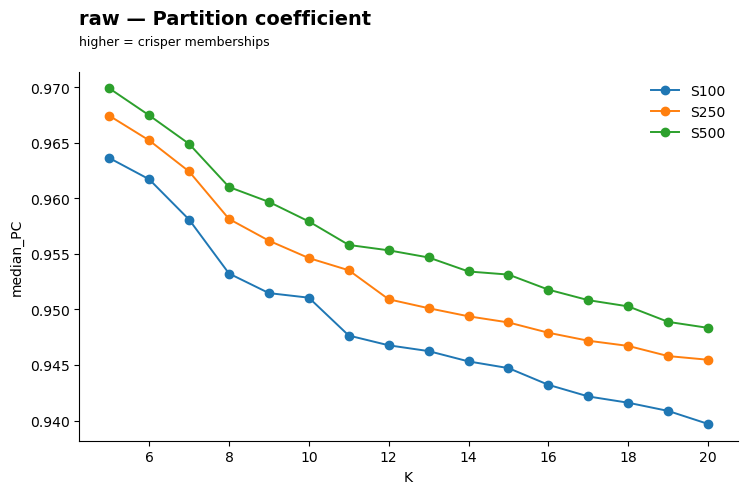

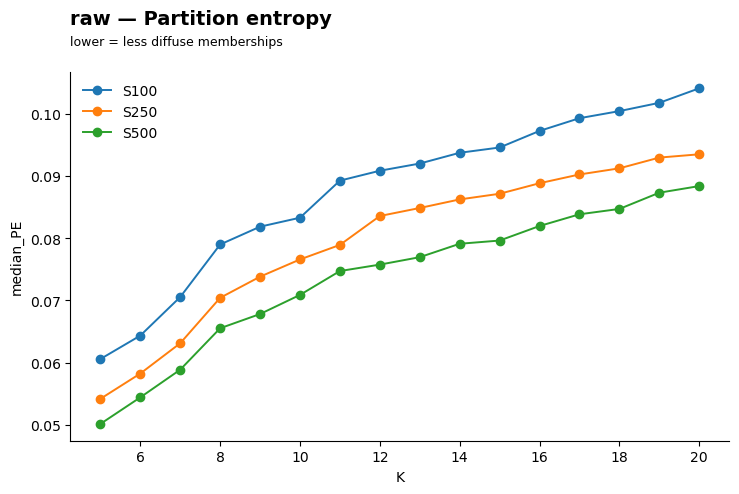

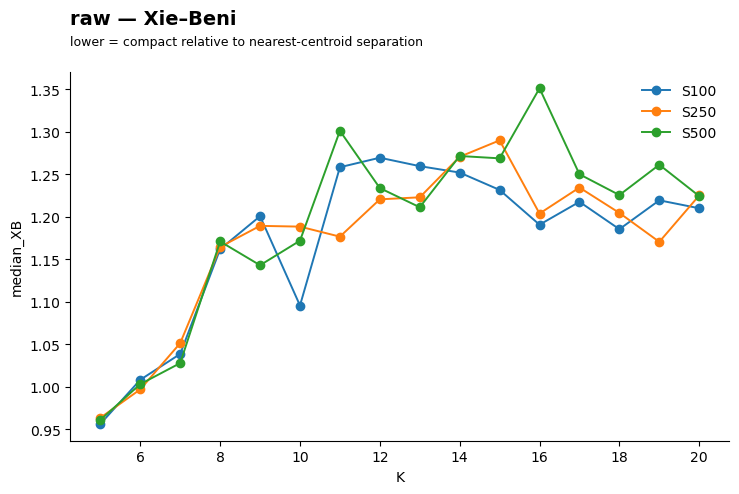

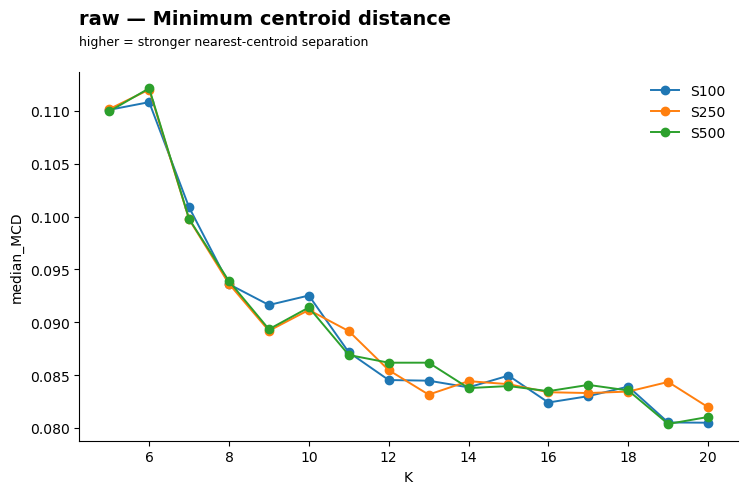

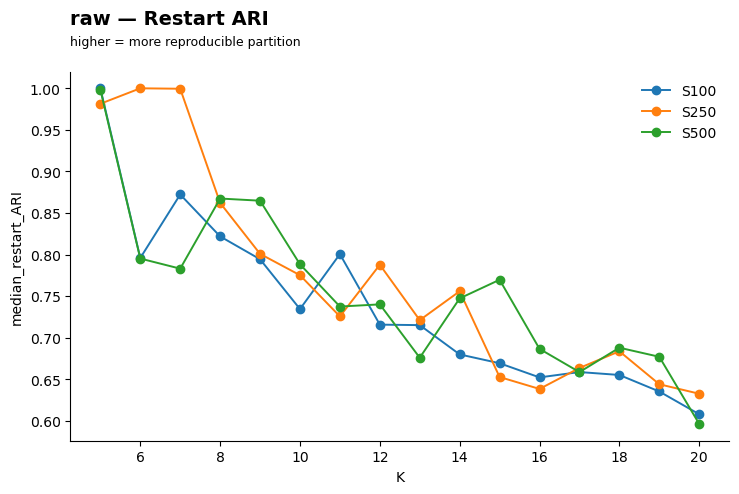

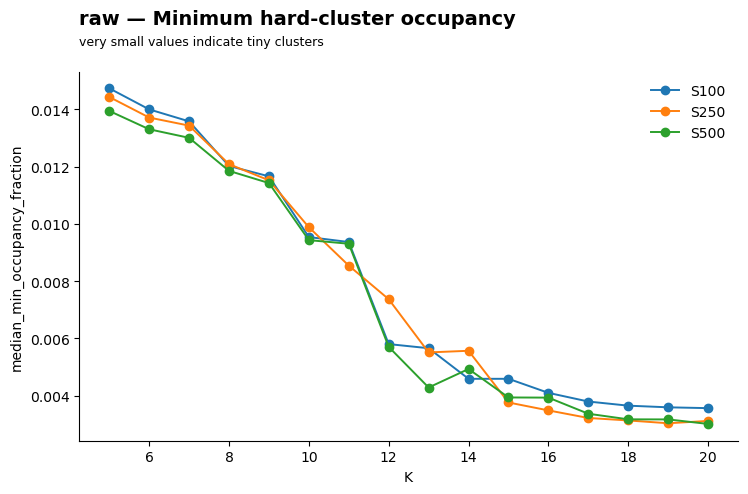

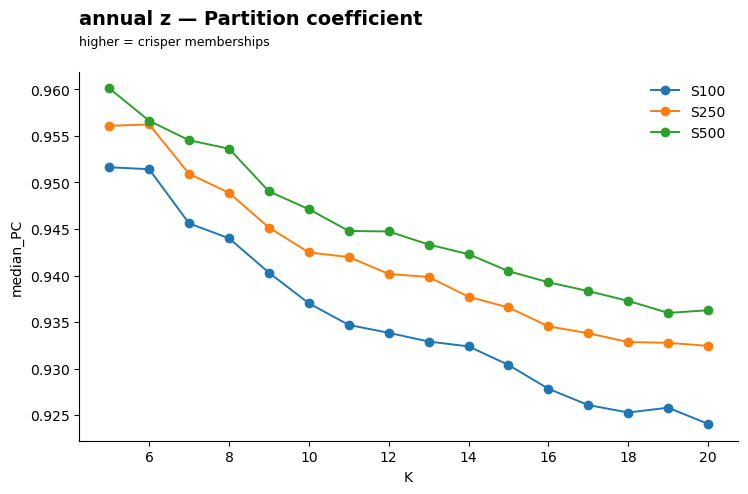

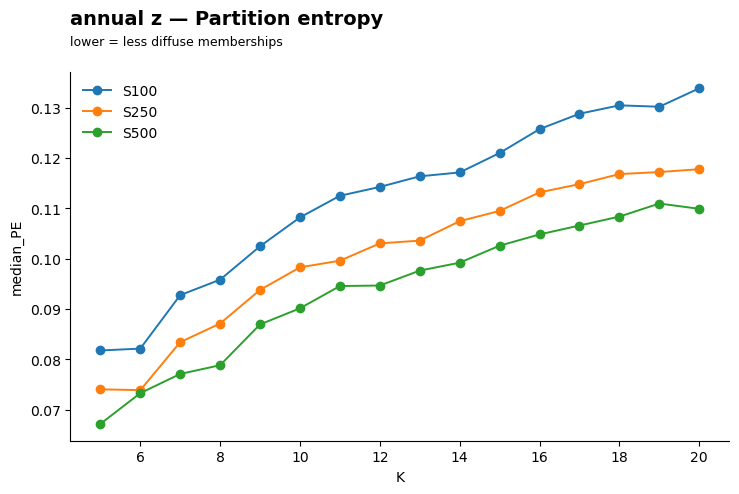

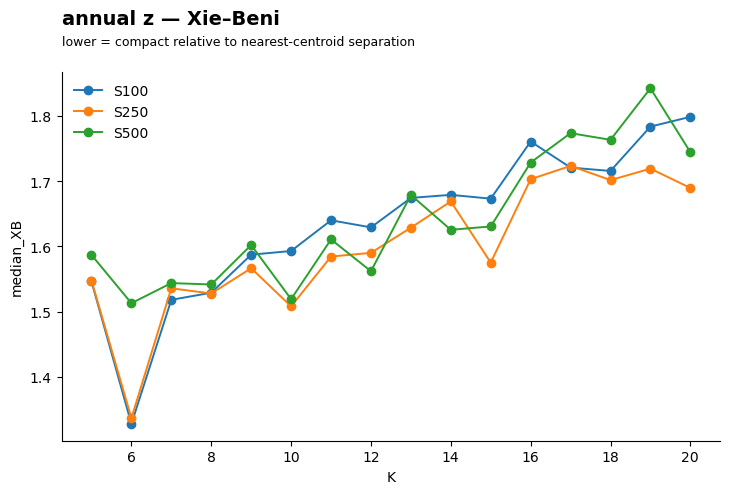

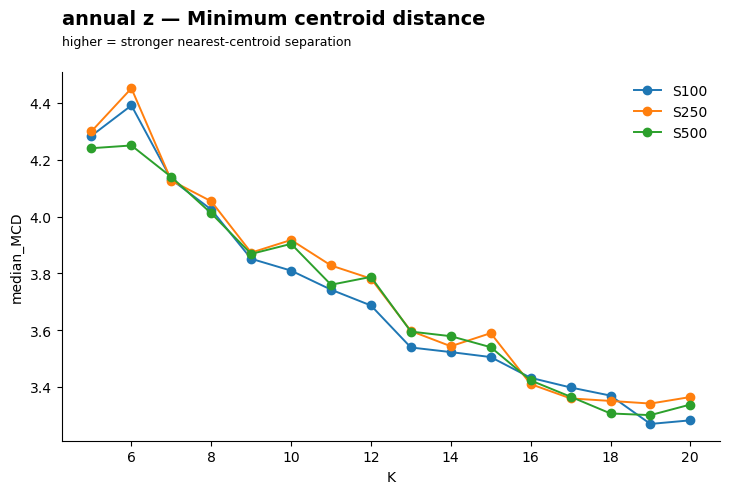

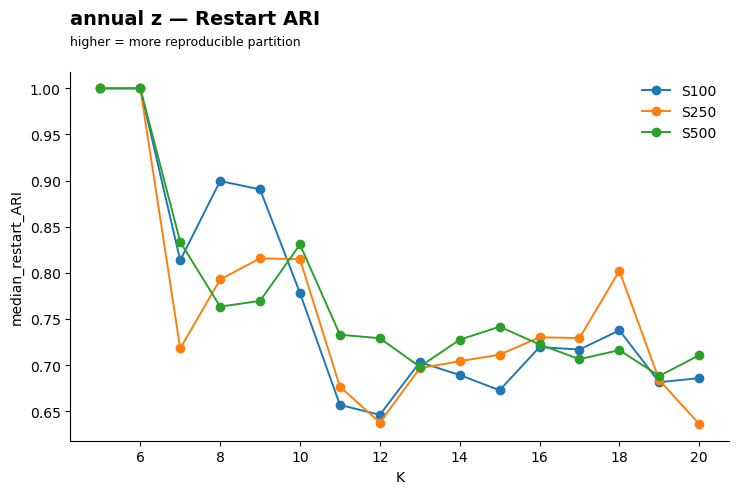

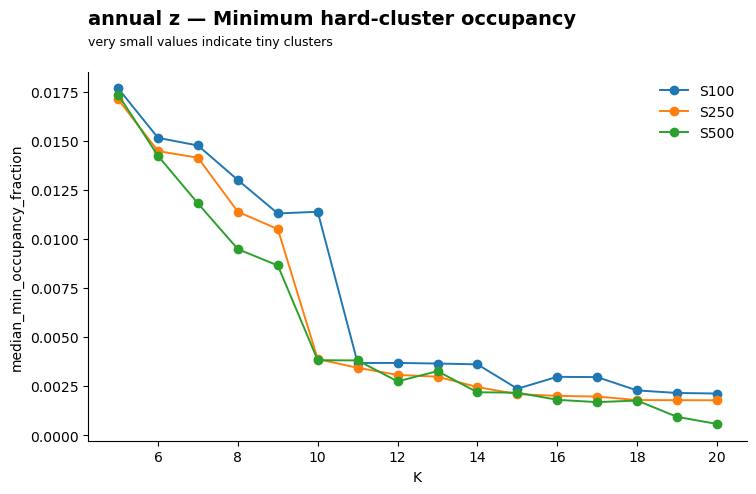

In [12]:
# =============================================================================
# 11. METRIC FIGURES
# =============================================================================

metric_specs = [
    (
        "median_PC",
        "Partition coefficient",
        "higher = crisper memberships",
    ),
    (
        "median_PE",
        "Partition entropy",
        "lower = less diffuse memberships",
    ),
    (
        "median_XB",
        "Xie–Beni",
        "lower = compact relative to nearest-centroid separation",
    ),
    (
        "median_MCD",
        "Minimum centroid distance",
        "higher = stronger nearest-centroid separation",
    ),
    (
        "median_restart_ARI",
        "Restart ARI",
        "higher = more reproducible partition",
    ),
    (
        "median_min_occupancy_fraction",
        "Minimum hard-cluster occupancy",
        "very small values indicate tiny clusters",
    ),
]


for geometry in GEOMETRIES:

    sub = aggregate_summary.loc[
        aggregate_summary[
            "geometry"
        ].eq(
            geometry
        )
    ]


    for metric, title, subtitle in metric_specs:

        fig, ax = plt.subplots(
            figsize=(
                8.5,
                5.2,
            )
        )


        for tier in SAMPLE_TIERS:

            line = (
                sub.loc[
                    sub[
                        "tier_n"
                    ].eq(
                        tier
                    )
                ]
                .sort_values(
                    "K"
                )
            )


            ax.plot(
                line[
                    "K"
                ],
                line[
                    metric
                ],
                marker="o",
                linewidth=1.4,
                label=f"S{tier}",
            )


        fig.subplots_adjust(
            top=0.82
        )


        fig.text(
            0.125,
            0.94,
            f"{geometry.replace('_', ' ')} — {title}",
            fontsize=14,
            fontweight="bold",
            ha="left",
            va="top",
        )


        fig.text(
            0.125,
            0.89,
            subtitle,
            fontsize=9,
            ha="left",
            va="top",
        )


        ax.set_xlabel(
            "K"
        )

        ax.set_ylabel(
            metric
        )

        ax.legend(
            frameon=False
        )


        ax.spines[
            "top"
        ].set_visible(
            False
        )

        ax.spines[
            "right"
        ].set_visible(
            False
        )


        fig.savefig(
            OUTPUT_DIR
            / (
                f"OpticalFCM_{geometry}_"
                f"{metric}.png"
            ),
            dpi=300,
            bbox_inches="tight",
        )


        plt.show()

        plt.close(
            fig
        )

## 12. Optional external validation at field-observed points

This section does **not** refit FCM at field points.

Instead, each field observation is transformed into the same raw or annual-z geometry and assigned to the landscape-derived centroids for its year. Parent/subcluster ARI and NMI are therefore external diagnostics of a clustering learned independently from the vegetation labels.

In [15]:
# =============================================================================
# 12. OPTIONAL FIELD-POINT PROJECTION
# =============================================================================

if RUN_FIELD_PROJECTION:

    if not FIELD_IA45_CSV.exists():

        raise FileNotFoundError(
            f"Field IA45 dataset not found:\n{FIELD_IA45_CSV}"
        )


    field = pd.read_csv(
        FIELD_IA45_CSV,
        low_memory=False,
    ).drop(
        columns=[
            "Unnamed: 0",
        ],
        errors="ignore",
    )


    missing_features = [
        c
        for c in IA_COLS
        if c not in field.columns
    ]


    if missing_features:

        raise KeyError(
            "Field dataset is missing IA45 features:\n"
            f"{missing_features[:10]}"
        )


    centroids_df = pd.read_csv(
        CENTROIDS_PATH
    )


    external_rows = []


    for key, centroid_group in centroids_df.groupby(
        [
            "Year",
            "tier_n",
            "geometry",
            "K",
            "m",
        ],
        sort=True,
    ):

        (
            year,
            tier,
            geometry,
            K,
            m,
        ) = key


        field_year = field.loc[
            pd.to_numeric(
                field[
                    "Year"
                ],
                errors="coerce",
            ).eq(
                year
            )
        ].copy()


        if len(
            field_year
        ) == 0:

            continue


        X_field_raw = (
            field_year[
                IA_COLS
            ]
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .to_numpy(
                dtype=np.float64
            )
        )


        valid = np.isfinite(
            X_field_raw
        ).all(
            axis=1
        )


        field_year = field_year.loc[
            valid
        ].copy()


        X_field_raw = X_field_raw[
            valid
        ]


        if geometry == "raw":

            X_field = X_field_raw

        else:

            X_field = (
                X_field_raw
                - ZSCORE_LOOKUP[
                    int(
                        year
                    )
                ][
                    "mean"
                ]
            ) / ZSCORE_LOOKUP[
                int(
                    year
                )
            ][
                "sd"
            ]


        centers = (
            centroid_group
            .sort_values(
                "cluster"
            )[
                IA_COLS
            ]
            .to_numpy(
                dtype=np.float64
            )
        )


        D = cdist(
            X_field,
            centers,
            metric="euclidean",
        )


        U = membership_from_distances(
            D=D,
            m=float(
                m
            ),
        )


        hard = (
            np.argmax(
                U,
                axis=1,
            )
            + 1
        )


        row = {
            "Year": int(
                year
            ),
            "tier_n": int(
                tier
            ),
            "geometry": geometry,
            "K": int(
                K
            ),
            "m": float(
                m
            ),
            "n_field": len(
                field_year
            ),
        }


        for label_col, prefix in [
            (
                "parent_cluster",
                "parent",
            ),
            (
                "state_id",
                "state",
            ),
        ]:

            if label_col not in field_year.columns:

                continue


            label = field_year[
                label_col
            ]


            label_valid = label.notna().to_numpy()


            if label_valid.sum() < 2:

                row[
                    f"ARI_{prefix}"
                ] = np.nan

                row[
                    f"NMI_{prefix}"
                ] = np.nan

                row[
                    f"n_{prefix}"
                ] = int(
                    label_valid.sum()
                )

            else:

                reference = (
                    label.loc[
                        label_valid
                    ]
                    .astype(str)
                    .to_numpy()
                )


                optical = hard[
                    label_valid
                ]


                row[
                    f"ARI_{prefix}"
                ] = float(
                    adjusted_rand_score(
                        reference,
                        optical,
                    )
                )


                row[
                    f"NMI_{prefix}"
                ] = float(
                    normalized_mutual_info_score(
                        reference,
                        optical,
                        average_method="arithmetic",
                    )
                )


                row[
                    f"n_{prefix}"
                ] = int(
                    label_valid.sum()
                )


        external_rows.append(
            row
        )


    external_df = pd.DataFrame(
        external_rows
    )


    external_df.to_csv(
        OUTPUT_DIR
        / "OpticalFCM_field_external_validation.csv",
        index=False,
    )


    display(
        external_df.head(
            30
        )
    )


else:

    print(
        "RUN_FIELD_PROJECTION=False — external field projection skipped."
    )

,Year,tier_n,geometry,K,m,n_field,ARI_parent,NMI_parent,n_parent,ARI_state,NMI_state,n_state
0,2016,100,annual_z,5,1.042326,255,0.110792,0.203370,255,0.072466,0.210689,255
1,2016,100,annual_z,6,1.042326,255,0.130762,0.238798,255,0.088554,0.247332,255
2,2016,100,annual_z,7,1.042326,255,0.139318,0.270408,255,0.084336,0.269310,255
3,2016,100,annual_z,8,1.042326,255,0.133064,0.258428,255,0.082451,0.267076,255
4,2016,100,annual_z,9,1.042326,255,0.141597,0.265824,255,0.096432,0.284268,255
5,2016,100,annual_z,10,1.042326,255,0.153515,0.301979,255,0.118113,0.336677,255
6,2016,100,annual_z,11,1.042326,255,0.129027,0.268211,255,0.086298,0.306901,255
7,2016,100,annual_z,12,1.042326,255,0.119055,0.270782,255,0.086874,0.311847,255
8,2016,100,annual_z,13,1.042326,255,0.106194,0.263659,255,0.091418,0.309915,255
9,2016,100,annual_z,14,1.042326,255,0.108245,0.280102,255,0.093930,0.328313,255


## Interpretation guide

The raw and annual-z analyses answer different geometric questions.

**Raw IA45** asks whether optical types emerge when native feature magnitudes determine Euclidean distance. Features with larger numerical variance exert more influence.

**Annual z IA45** asks whether optical types emerge after every feature is expressed as a standardized annual deviation from that year's landscape distribution. Each feature has comparable variance, and broad annual displacement is removed.

A candidate K is more compelling when its regime is supported across:

- several years;
- more than one sample tier;
- both raw and annual-z geometries;
- favorable XB / MCD;
- non-pathological occupancy;
- strong restart reproducibility.

Raw and annual-z need not produce identical K. A difference is scientifically interpretable because they encode different definitions of optical distance.

No final K should be selected solely from one validity index.